# BetFlow — Analisi delle transazioni di SatoshiDice

Il presente elaborato analizza l'attività di SatoshiDice attraverso i dati pubblicamente disponibili sulla blockchain Bitcoin. L'obiettivo principale consiste nel ricostruire il flusso delle transazioni di scommessa e dei relativi payout, esaminare il comportamento degli utenti e individuare eventuali catene di puntate tra loro collegate.

## Indice

1. **Fase 1 — Preparazione e controllo dei dati**
2. **Fase 2 — Modellazione dei dati e ricostruzione degli UTXO**
3. **Fase 3 — Analisi di sequenze di bet**
4. **Fase 4 — Scraping di WalletExplorer per verificare appartenenza a wallet**

## Fase 1 — Preparazione e controllo dei dati

La prima fase è dedicata alla predisposizione dell'ambiente di lavoro e alla valutazione preliminare della qualità dei dati. In particolare, vengono documentate la struttura e la provenienza dei dataset e vengono esaminati il numero di osservazioni, le colonne disponibili, i tipi di dato, la presenza di duplicati o valori mancanti e l'intervallo temporale coperto. Viene inoltre verificata l'unità di misura degli importi monetari.

### 1.1) Importazione delle librerie e verifica dell'ambiente

La cella importa le librerie utilizzate nell'analisi, configura le opzioni di visualizzazione di pandas, imposta un seme per la riproducibilità e stampa le versioni principali dell'ambiente di esecuzione.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import platform
import sys

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)
SEED = 42

print(f"Python: {sys.version.split()[0]}")
print(f"Piattaforma: {platform.platform()}")
print(f"pandas: {pd.__version__} | numpy: {np.__version__}")

Python: 3.10.15
Piattaforma: macOS-26.5.2-arm64-arm-64bit
pandas: 2.3.3 | numpy: 2.2.6


### 1.2) Configurazione dell'ambiente di lavoro

La cella seguente definisce le costanti e le strutture di supporto necessarie per garantire una gestione coerente e riproducibile dei dati. Nello specifico:

- individua la directory principale del progetto;
- consente di selezionare una modalità di caricamento campionaria oppure completa, in funzione delle risorse computazionali disponibili;
- stabilisce il fattore di conversione tra Bitcoin e satoshi (`1 BTC = 100.000.000 satoshi`);
- raccoglie nel dizionario `DATASETS` i percorsi, i separatori e gli schemi necessari alla lettura dei file.

In [2]:
PROJECT_DIR = Path.cwd().resolve()
RAW_DATA_DIR = PROJECT_DIR

SATOSHI_PER_BTC = 100_000_000

# False: usa un campione; True: carica tutte le righe dei dataset.
FULL_VALIDATION = True
SAMPLE_SIZE = 100_000
SAMPLE_ROWS = None if FULL_VALIDATION else SAMPLE_SIZE

DATASETS = {
    "transactions": {
        "path": RAW_DATA_DIR / "transactions.csv",
        "sep": ",",
        "columns": ["timestamp", "blockId", "txId", "isCoinbase", "fee"],
    },
    "inputs": {
        "path": RAW_DATA_DIR / "inputs.csv",
        "sep": ",",
        "columns": ["txId", "prevTxId", "prevTxPos"],
    },
    "outputs": {
        "path": RAW_DATA_DIR / "outputs.csv",
        "sep": ",",
        "columns": ["txId", "position", "addressId", "amount_satoshi", "scriptType"],
    },
    "address_mapping": {
        "path": RAW_DATA_DIR / "mapAddr2Ids8708820.csv",
        "sep": ",",
        "columns": ["address", "addressId"],
    },
}
SATOSHI_DICE_PATH = RAW_DATA_DIR / "satoshiDiceInfos.tsv"

print(f"Cartella progetto: {PROJECT_DIR}")
print(
    "Modalità di caricamento: dataset completo"
    if FULL_VALIDATION
    else f"Modalità di caricamento: campione di {SAMPLE_ROWS:,} righe per file"
)

Cartella progetto: /Users/antoniofatticcioni/Desktop/Università/Lab_Web_Scraping/Progetto_Lab_web_scraping
Modalità di caricamento: dataset completo


### 1.3) Caricamento preliminare dei dataset

La cella seguente acquisisce i file che compongono la base dati e memorizza i corrispondenti DataFrame nel dizionario `frames`. Il file relativo a SatoshiDice viene trattato separatamente, poiché presenta una riga iniziale contenente la fonte e una struttura dei separatori differente rispetto agli altri file. Per ciascun dataset vengono infine riportati il numero di righe, il numero di colonne e un'anteprima delle osservazioni, così da verificare la correttezza della procedura di lettura.

In [3]:
def read_headerless_dataset(config, nrows=SAMPLE_ROWS):
    return pd.read_csv(
        config["path"],
        sep=config["sep"],
        names=config["columns"],
        header=None,
        nrows=nrows,
        low_memory=False,
    )

frames = {name: read_headerless_dataset(cfg) for name, cfg in DATASETS.items()} #.items produce coppie chiave valore

# Il file SatoshiDice contiene una riga di provenienza prima dell'intestazione.
satoshi_dice = pd.read_csv(
    SATOSHI_DICE_PATH,
    sep=r"\t|\s{2,}",  # tab nell'header, spazi multipli nelle righe
    engine="python",
    skiprows=1,  # salta la riga iniziale contenente l'URL della fonte
)
satoshi_dice.columns = satoshi_dice.columns.str.strip()
satoshi_dice = satoshi_dice.apply(
    lambda column: column.str.strip() if column.dtype == "object" else column #rimuove spazi bianchi se colonna contiene testo
)
frames["satoshi_dice"] = satoshi_dice

for name, frame in frames.items():
    print(f"{name}: {frame.shape[0]:,} righe × {frame.shape[1]} colonne")
    display(frame.head(6))

outputs = frames["outputs"].copy()
transactions = frames["transactions"].copy()
mapping = frames["address_mapping"].copy()
inputs = frames["inputs"].copy()
satoshi_dice = frames["satoshi_dice"].copy()

transactions: 10,532,115 righe × 5 colonne


,timestamp,blockId,txId,isCoinbase,fee
0,1231473279,9,9,1,0
1,1231635654,78,78,1,0
2,1231731025,170,171,0,0
3,1231740133,181,183,0,0
4,1231740736,182,185,0,0
5,1231742062,183,187,0,0


inputs: 21,378,770 righe × 3 colonne


,txId,prevTxId,prevTxPos
0,171,9,0
1,183,171,1
2,185,183,1
3,187,185,1
4,192,187,0
5,227,185,0


outputs: 24,573,071 righe × 5 colonne


,txId,position,addressId,amount_satoshi,scriptType
0,9,0,9,5000000000,1
1,78,0,78,5000000000,1
2,171,0,171,1000000000,1
3,171,1,9,4000000000,1
4,183,0,183,1000000000,1
5,183,1,9,3000000000,1


address_mapping: 8,708,821 righe × 2 colonne


,address,addressId
0,1A1zP1eP5QGefi2DMPTfTL5SLmv7DivfNa,0
1,12c6DSiU4Rq3P4ZxziKxzrL5LmMBrzjrJX,1
2,1HLoD9E4SDFFPDiYfNYnkBLQ85Y51J3Zb1,2
3,1FvzCLoTPGANNjWoUo6jUGuAG3wg1w4YjR,3
4,15ubicBBWFnvoZLT7GiU2qxjRaKJPdkDMG,4
5,1JfbZRwdDHKZmuiZgYArJZhcuuzuw2HuMu,5


satoshi_dice: 27 righe × 8 colonne


,Name,Address,WinOdds,PriceMultiplier,HousePercentage,ExpectReturn,MinimumBet,MaximumBet
0,lessthan 64000,1dice9wVtrKZTBbAZqz1XiTmboYyvpD3t,97.6563%,1.004x,1.900%,98.100%,0.01,500.0000
1,lessthan 60000,1diceDCd27Cc22HV3qPNZKwGnZ8QwhLTc,91.5527%,1.071x,1.900%,98.100%,0.01,500.0000
2,lessthan 56000,1dicegEArYHgbwQZhvr5G9Ah2s7SFuW1y,85.4492%,1.147x,1.900%,98.100%,0.01,500.0000
3,lessthan 52000,1dicec9k7KpmQaA8Uc8aCCxfWnwEWzpXE,79.3457%,1.235x,1.900%,98.100%,0.01,500.0000
4,lessthan 48000,1dice9wcMu5hLF4g81u8nioL5mmSHTApw,73.2422%,1.338x,1.900%,98.100%,0.01,500.0000
5,lessthan 32768,1dice97ECuByXAvqXpaYzSaQuPVvrtmz6,50.0000%,1.957x,1.900%,98.100%,0.01,463.5871


### 1.4) Controllo preliminare della qualità dei dati

Il codice seguente produce un riepilogo della struttura dei dataset, riportando per ciascuna variabile il tipo di dato inferito, il numero di valori presenti e mancanti e il numero di valori distinti. Viene inoltre calcolata la quantità di righe duplicate. Qualora sia attiva la modalità campionaria, i risultati si riferiscono esclusivamente alle prime `SAMPLE_ROWS` osservazioni e non devono pertanto essere interpretati come statistiche relative all'intera base dati.

In [4]:
def quality_report(name: str, frame: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "dataset": name,
        "column": frame.columns,
        "dtype": frame.dtypes.astype(str).values,
        "non_null": frame.notna().sum().values,
        "missing": frame.isna().sum().values,
        "unique": frame.nunique(dropna=True).values
    })

quality = pd.concat(
    [quality_report(name, frame) for name, frame in frames.items()],
    ignore_index=True,
)
duplicates = pd.DataFrame([
        {"dataset": name,
         "rows_checked": len(frame),
         "duplicate_rows": int(frame.duplicated().sum()
        )}
    for name, frame in frames.items()
    ])

display(quality)
display(duplicates)

,dataset,column,dtype,non_null,missing,unique
0,transactions,timestamp,int64,10532115,0,181012
1,transactions,blockId,int64,10532115,0,181089
2,transactions,txId,int64,10532115,0,10532115
3,transactions,isCoinbase,int64,10532115,0,2
4,transactions,fee,int64,10532115,0,25134
5,inputs,txId,int64,21378770,0,10358266
6,inputs,prevTxId,int64,21378770,0,10478360
7,inputs,prevTxPos,int64,21378770,0,2204
8,outputs,txId,int64,24573071,0,10532115
9,outputs,position,int64,24573071,0,2793


,dataset,rows_checked,duplicate_rows
0,transactions,10532115,0
1,inputs,21378770,0
2,outputs,24573071,0
3,address_mapping,8708821,0
4,satoshi_dice,27,0


### 1.5) Unità di misura degli importi e conversione in Bitcoin

Nei dataset usati gli importi sono espressi in **satoshi**, ossia la più piccola unità frazionaria di Bitcoin. La conversione adottata è `1 BTC = 100.000.000 satoshi`. Per garantire la tracciabilità dell'elaborazione, la variabile originale `amount_satoshi` viene conservata senza modifiche, mentre l'importo convertito è memorizzato nella nuova variabile `amount_btc`. Le statistiche descrittive consentono di effettuare un primo controllo sulla plausibilità dei valori ottenuti.


In [5]:
outputs["amount_btc"] = outputs["amount_satoshi"] / SATOSHI_PER_BTC
transactions["fee_btc"] = transactions["fee"] / SATOSHI_PER_BTC

La cella converte i timestamp in date UTC e verifica che non siano presenti `txId` mancanti o importi negativi.

In [6]:
transactions["datetime_utc"] = pd.to_datetime(
    transactions["timestamp"], unit="s", utc=True, errors="coerce"
)

assert transactions["txId"].notna().all(), "txId mancanti nel campione delle transazioni."
assert (frames["outputs"]["amount_satoshi"] >= 0).all(), "Trovati output con importo negativo."

### 1.6) Dizionario preliminare dei dati

La tabella seguente sintetizza il significato attribuito alle variabili sulla base della documentazione disponibile e dell'ispezione iniziale dei file. Le definizioni saranno sottoposte a ulteriore verifica durante la ricostruzione delle relazioni tra input e output.

| Dataset | Campo | Significato preliminare |
|---|---|---|
| transactions | timestamp | Unix timestamp della transazione (secondi, UTC) |
| transactions | blockId | Identificativo/altezza del blocco |
| transactions | txId | Identificativo numerico interno della transazione |
| transactions | isCoinbase | Indicatore di transazione coinbase |
| transactions | fee | Commissione della transazione; unità da verificare sui dati |
| inputs | txId | Transazione che spende l'output precedente |
| inputs | prevTxId, prevTxPos | Chiave dell'UTXO precedente speso |
| outputs | txId, position | Chiave dell'output/UTXO |
| outputs | addressId | Identificativo interno dell'indirizzo destinatario |
| outputs | amount_satoshi | Importo dell'output in satoshi |
| outputs | scriptType | Codice del tipo di script |
| address_mapping | address, addressId | Associazione indirizzo Bitcoin ↔ ID interno |
| satoshi_dice | Name, Address | Nome della bet e indirizzo `1dice` |
| satoshi_dice | WinOdds, PriceMultiplier | Probabilità di vincita e moltiplicatore |
| satoshi_dice | HousePercentage, ExpectReturn | Margine del banco e rendimento atteso |
| satoshi_dice | MinimumBet, MaximumBet | Limiti dichiarati della puntata |

## Fase 2 — Modellazione dei dati e plotting

Questa fase è dedicata alla definizione delle chiavi di collegamento tra i dataset e all'analisi dei dati. In particolare, vengono esaminate le relazioni basate su `txId`, sulla coppia `txId-position`, sui riferimenti `prevTxId-prevTxPos` e su `addressId` e su di esse vengono effettuate varie analisi, i cui risultati vengono mostrati da grafici che ne consentono una visualizzazione appropriata.

### 2.1) Identificazione delle transazioni di bet

La cella unisce transazioni, output e indirizzi, seleziona le operazioni dirette a indirizzi `1dice`
e ne analizza il numero di output per transazione. vengono mostrati due dataframe:
- il primo, `timeSBetTransactions`, è un dataframe ordinato temporalmente che mostra le informazioni relative alle transizioni di bet
- il secondo è un dataframe che mostra quante transizioni esistono che hanno un determinato numero di output di bet, dove ogni output è identificato univocamente dalla tupla `(txId, position)`.

In [7]:
transactionsOutput = pd.merge(transactions, outputs, on="txId")
mappingTransactionsOutput = pd.merge(transactionsOutput, mapping, on="addressId")
timeSMappingTransactionsOutput = mappingTransactionsOutput.set_index('datetime_utc')

betTransactions = mappingTransactionsOutput.loc[
    mappingTransactionsOutput.address.str.startswith('1dice', na=False)
]
timeSBetTransactions = betTransactions.set_index('datetime_utc')

totTransactions = mappingTransactionsOutput.loc[:,['address','addressId','txId']]
timeSTotTransactions = timeSMappingTransactionsOutput.loc[:,['address','addressId','txId']]

idTransactions = betTransactions.groupby("txId")["position"].count().rename("NumOperazioni").reset_index()

display(timeSBetTransactions)
display(idTransactions.groupby("NumOperazioni").size().rename("NumeroTransazioni").reset_index())

,timestamp,blockId,txId,isCoinbase,fee,fee_btc,position,addressId,amount_satoshi,scriptType,amount_btc,address
datetime_utc,,,,,,,,,,,,
2012-04-21 17:02:44+00:00,1335027764,176627,2883791,0,50000,0.0005,1,3517234,2000000,2,0.02,1dice6DPtUMBpWgv8i4pG8HMjXv9qDJWN
2012-04-21 17:28:41+00:00,1335029321,176629,2883916,0,0,0.0000,1,3517234,2000000,2,0.02,1dice6DPtUMBpWgv8i4pG8HMjXv9qDJWN
2012-04-21 17:28:41+00:00,1335029321,176629,2883948,0,50000,0.0005,1,3517234,2000000,2,0.02,1dice6DPtUMBpWgv8i4pG8HMjXv9qDJWN
2012-04-21 17:28:41+00:00,1335029321,176629,2883966,0,50000,0.0005,1,3517234,2000000,2,0.02,1dice6DPtUMBpWgv8i4pG8HMjXv9qDJWN
2012-04-21 17:28:41+00:00,1335029321,176629,2883974,0,50000,0.0005,1,3517234,2000000,2,0.02,1dice6DPtUMBpWgv8i4pG8HMjXv9qDJWN
...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 23:52:37+00:00,1356997957,214562,10572820,0,100000,0.0010,3,3534212,10000000,2,0.10,1dice7fUkz5h4z2wPc1wLMPWgB5mDwKDx
2012-12-31 23:52:37+00:00,1356997957,214562,10572820,0,100000,0.0010,4,3535501,10000000,2,0.10,1dice7EYzJag7SxkdKXLr8Jn14WUb3Cf1
2012-12-31 23:52:37+00:00,1356997957,214562,10572820,0,100000,0.0010,5,3525822,10000000,2,0.10,1dice6YgEVBf88erBFra9BHf6ZMoyvG88


,NumOperazioni,NumeroTransazioni
0,1,1834747
1,2,56565
2,3,29337
3,4,16349
4,5,6153
...,...,...
71,120,1
72,126,1
73,208,1
74,209,1


### 2.2) Andamento temporale della percentuale di bet

La cella conta le transazioni totali e le transazioni di bet distinte per settimana,giorno e ora e successivamente calcola la quota percentuale delle bet sul totale.

In [8]:
betTransactions_week = timeSBetTransactions["txId"].resample("W").nunique()
totTransactions_week = timeSTotTransactions["txId"].resample("W").nunique()

percentuali_bet_week = pd.DataFrame({
    "transazioni_totali": totTransactions_week,
    "transazioni_bet": betTransactions_week
}).fillna(0)

percentuali_bet_week["percentuale_bet"] = (
    percentuali_bet_week["transazioni_bet"]
    .div(percentuali_bet_week["transazioni_totali"])
    .mul(100)
    .fillna(0)
    .round(2)
)


# Aggregazione giornaliera
betTransactions_day = timeSBetTransactions["txId"].resample("D").nunique()
totTransactions_day = timeSTotTransactions["txId"].resample("D").nunique()

percentuali_bet_day = pd.DataFrame({
    "transazioni_totali": totTransactions_day,
    "transazioni_bet": betTransactions_day
}).fillna(0)

percentuali_bet_day["percentuale_bet"] = (
    percentuali_bet_day["transazioni_bet"]
    .div(percentuali_bet_day["transazioni_totali"])
    .mul(100)
    .fillna(0)
    .round(2)
)


# Aggregazione oraria
betTransactions_hour = timeSBetTransactions["txId"].resample("h").nunique()
totTransactions_hour = timeSTotTransactions["txId"].resample("h").nunique()

percentuali_bet_hour = pd.DataFrame({
    "transazioni_totali": totTransactions_hour,
    "transazioni_bet": betTransactions_hour
}).fillna(0)

percentuali_bet_hour["percentuale_bet"] = (
    percentuali_bet_hour["transazioni_bet"]
    .div(percentuali_bet_hour["transazioni_totali"])
    .mul(100)
    .fillna(0)
    .round(2)
)

#### 2.2.1) Line plot per andamento temporale della percentuale di bet

I grafici sottostanti rappresentano l'evoluzione oraria, giornaliera e settimanale della percentuale di transazioni associate a SatoshiDice nel periodo temporale considerato. Le prime transizioni ad un indirizzo di bet vengono effettuate verso metà aprile del 2012, quindi il `2012-04-20` è stato preso come limite sinistro per l'asse x in ogni grafico.
- **Percentuale di bet oraria**: Il grafico presenta oscillazioni molto ampie, visto che in ogni ora ci sono meno transazioni anche poche bet possono modificare molto la percentuale
- **Percentuale di bet giornaliera**: la percentuale cresce rapidamente tra aprile e maggio, raggiungendo valori vicini al 40%. Dopo il picco di maggio-giugno diminuisce e si stabilizza prevalentemente tra il `20%` e il `30%`, mantenendo comunque alcune oscillazioni.
- **Percentuale di bet settimanale**: l’aggregazione settimanale riduce le oscillazioni e rende più evidente l’andamento generale. Dopo una forte crescita iniziale e un picco superiore al `35%`, la percentuale scende intorno al `20–25%` e rimane relativamente stabile, mostrando una lieve crescita negli ultimi mesi.



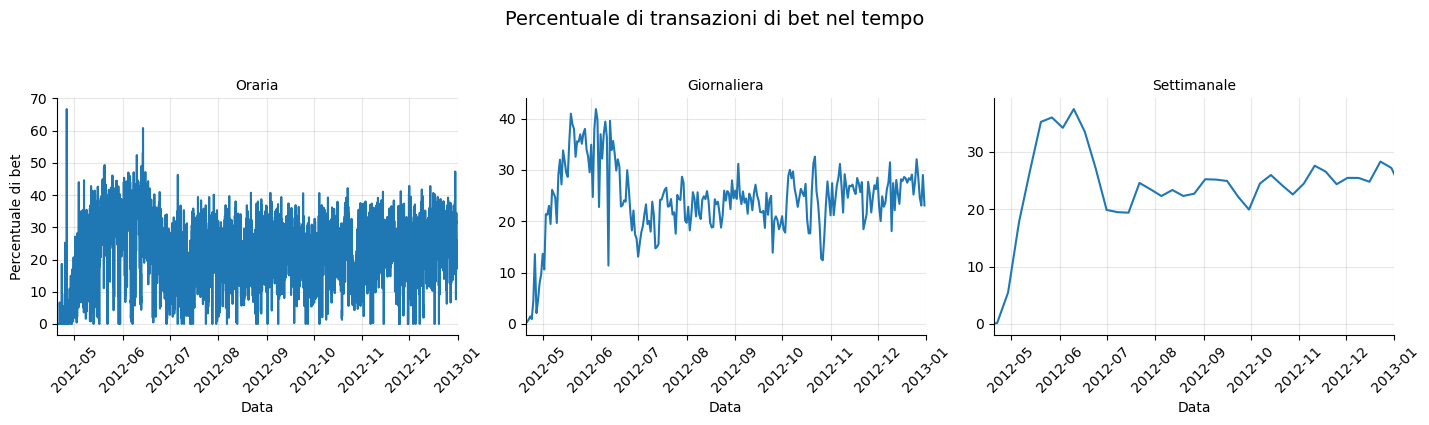

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

percentuali_confronto = pd.concat([
    percentuali_bet_hour.reset_index().assign(Scala="Oraria"), #assign aggiunge una nuova colonna al DataFrame e restituisce una copia modificata
    percentuali_bet_day.reset_index().assign(Scala="Giornaliera"),
    percentuali_bet_week.reset_index().assign(Scala="Settimanale")
])

graph = sns.relplot(
    data=percentuali_confronto,
    x="datetime_utc",
    y="percentuale_bet",
    col="Scala",
    kind="line",
    col_wrap=3,
    height=4,
    aspect=1.2,
    facet_kws={
        "sharex": False,
        "sharey": False
    }
)

graph.set_axis_labels(
    "Data",
    "Percentuale di bet"
)

graph.set_titles("{col_name}")

for axis in graph.axes.flat:
    axis.set_xlim(
        pd.Timestamp("2012-04-20", tz="UTC"),
        pd.Timestamp("2013-01-01", tz="UTC")
    )
    axis.tick_params(
        axis="x",
        rotation=45
    )
    axis.grid(alpha=0.3)

graph.figure.suptitle(
    "Percentuale di transazioni di bet nel tempo",
    fontsize=14,
    y=1.05
)

plt.tight_layout()
plt.show()

### 2.3) Popolarità degli indirizzi di betting
la popolarità di ogni indirizzo di betting viene calcolata considerando,
rispettivamente, il numero di bet per ogni indirizzo con prefisso `1dice` contenuto
nel file e l’amount complessivo delle bet per quell’indirizzo.

La cella calcola le somme (sia in Bitcoin che in Satoshi) di tutti gli output relativi ad ogni transazione. Successivamente calcola la popolarità di ogni indirizzo di betting e il rispettivo amount complessivo delle bet, conservando i dati nel dataset `popularity`

In [10]:
sumBetTransactions=betTransactions.groupby(['txId','address']).agg(
    complexiveAmountSatoshi=("amount_satoshi","sum"),
    complexiveAmountBtc=("amount_btc","sum")
)
sumBetTransactions=sumBetTransactions.reset_index('txId')

satoshiTransactions=pd.merge(
    sumBetTransactions,
    satoshi_dice,
    left_on="address",
    right_on="Address",
    how="inner")

popularity = (
satoshiTransactions.groupby("Name").agg(
        numberOfBets=("txId","nunique"),
        totalAmountSatoshi=("complexiveAmountSatoshi","sum"),
        totalAmountBtc=("complexiveAmountBtc","sum")
    )
)
display(popularity)


,numberOfBets,totalAmountSatoshi,totalAmountBtc
Name,,,
lessthan 1,60417,57057284641,570.572846
lessthan 1000,72019,1785664070235,17856.640702
lessthan 12000,48532,6751217269093,67512.172691
lessthan 128,15490,181045842063,1810.458421
lessthan 1500,19852,600942077754,6009.420778
lessthan 16,9669,23680517710,236.805177
lessthan 16000,154832,14734136043673,147341.360437
lessthan 2,3511,5985865123,59.858651
lessthan 2000,42163,1748932963033,17489.329630


#### 2.3.1) Scatter plot per popolarità degli indirizzi di betting

Lo **scatter plot** confronta gli indirizzi in base al numero di bet e al volume complessivo in BTC; le scale logaritmiche rendono leggibili anche valori molto distanti tra loro.
Il grafico evidenzia una relazione generalmente positiva tra il `numero di bet` e l’`importo complessivo`. Tuttavia, alcuni indirizzi si discostano da questo andamento, indicando differenze nell’importo medio delle puntate. `lessthan 32000` risulta l’indirizzo più popolare secondo entrambe le misure.

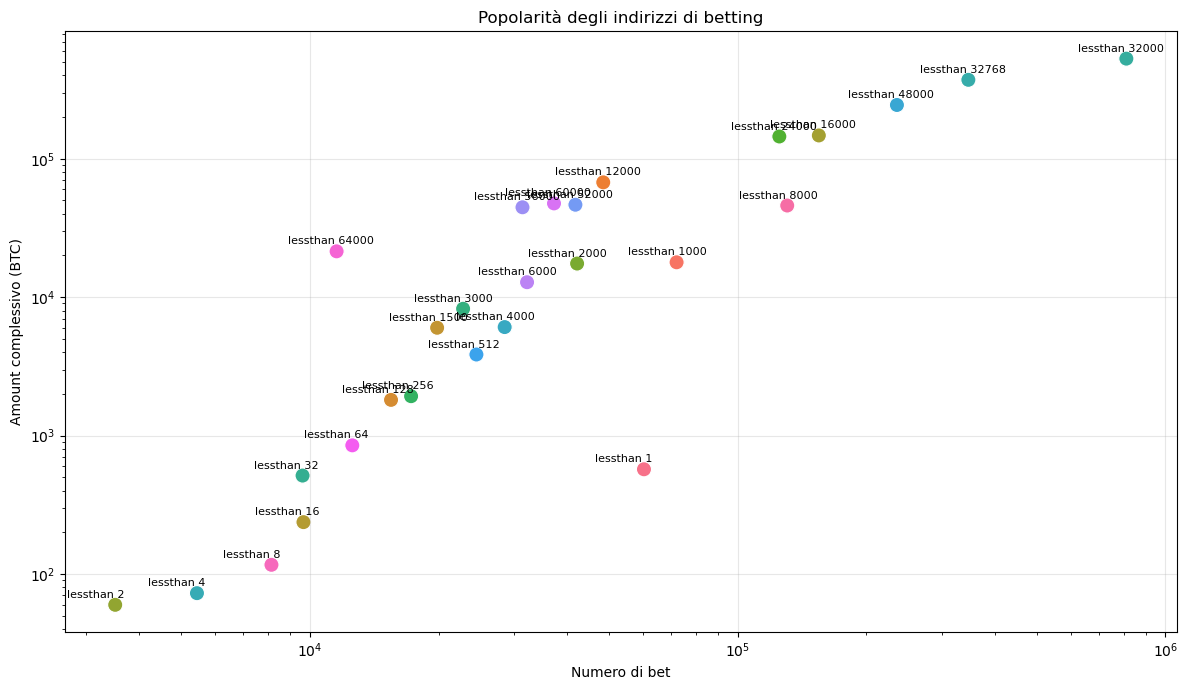

In [11]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=popularity,
    x="numberOfBets",
    y="totalAmountBtc",
    hue="Name",
    s=120,
    legend=False
)

if "Name" in popularity.index.names:
    popularity = popularity.reset_index()
    
for _, row in popularity.iterrows():
    plt.annotate(
        row["Name"],
        (row["numberOfBets"], row["totalAmountBtc"]),
        xytext=(-35, 5),#specifica spostamento testo
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Numero di bet")
plt.ylabel("Amount complessivo (BTC)")
plt.title("Popolarità degli indirizzi di betting")
plt.grid(alpha=0.3)
plt.xscale("log")
plt.yscale("log")
plt.tight_layout()
plt.show()

### 2.4) Distanza tra transazioni di bet e corrispondenti transazioni di payout
Valutare la distanza tra transazioni di bet e rispettive transazioni di payout. Una transazione di payout è considerata associata a una transazione di bet se un input della transazione consuma un UTXO della corrispondente transazione di bet (ovvero un
output non speso della transazione di bet).

La cella identifica gli output delle bet tramite la coppia `(txId, position)`. Questi vengono associati, mediante un merge, agli input che fanno riferimento alla stessa coppia attraverso `(prevTxId, prevTxPos)`, individuando così la transazione di payout che spende l’output della betSuccessivamente associa le date alle due transazioni, calcola il tempo trascorso tra bet e payout ed esclude le coppie con distanza temporale negativa. Le coppie valide sono salvate nel dataframe `validPairs`.

In [12]:
betUtxos = (
    betTransactions[["txId", "position", "datetime_utc"]]
    .rename(columns={"txId": "betTxId", "position": "betPosition", "datetime_utc": "betDate"})
)

payoutInputs = (
    inputs.loc[inputs["prevTxId"].isin(betUtxos["betTxId"])]
    .rename(columns={"txId": "payoutTxId","prevTxId": "betTxId","prevTxPos": "betPosition"})
)

betPayout = (
    betUtxos.merge(
        payoutInputs,
        on=["betTxId", "betPosition"],
        how="inner"
    )
    [["betTxId", "payoutTxId", "betDate"]]
     .drop_duplicates()
)

transactionDates = transactions[["txId", "datetime_utc"]]

betPayout = betPayout.merge(
    transactionDates.rename(
        columns={"txId": "payoutTxId", "datetime_utc": "payoutDate"}
    ),
    on="payoutTxId",
    how="inner"
)

betPayout["distance"] = betPayout["payoutDate"] - betPayout["betDate"]
betPayout["distanceMinutes"] = betPayout["distance"].dt.total_seconds() / 60

invalidPairs = betPayout.loc[betPayout["distance"] < pd.Timedelta(0)]
validPairs = betPayout.loc[betPayout["distance"] >= pd.Timedelta(0)]

print(f"Coppie valide: {len(validPairs):,}")
print(f"Coppie con distanza negativa: {len(invalidPairs):,}")
display(validPairs.sort_values(by="distanceMinutes", ascending=False))
display(invalidPairs)

Coppie valide: 2,336,744
Coppie con distanza negativa: 13,340


,betTxId,payoutTxId,betDate,payoutDate,distance,distanceMinutes
822602,5394220,7437736,2012-07-29 00:47:08+00:00,2012-09-26 21:39:28+00:00,59 days 20:52:20,86212.333333
822608,5394247,7437739,2012-07-29 00:47:08+00:00,2012-09-26 21:39:28+00:00,59 days 20:52:20,86212.333333
908233,5722829,7437744,2012-08-08 00:28:18+00:00,2012-09-26 21:39:28+00:00,49 days 21:11:10,71831.166667
1625366,8340704,9316839,2012-10-25 19:05:39+00:00,2012-11-27 20:31:05+00:00,33 days 01:25:26,47605.433333
1625365,8340702,9316844,2012-10-25 19:05:39+00:00,2012-11-27 20:31:05+00:00,33 days 01:25:26,47605.433333
...,...,...,...,...,...,...
902436,5695789,5695808,2012-08-07 01:51:53+00:00,2012-08-07 01:51:53+00:00,0 days 00:00:00,0.000000
902434,5695778,5695801,2012-08-07 01:51:53+00:00,2012-08-07 01:51:53+00:00,0 days 00:00:00,0.000000
902433,5695778,5695802,2012-08-07 01:51:53+00:00,2012-08-07 01:51:53+00:00,0 days 00:00:00,0.000000
902432,5695778,5695800,2012-08-07 01:51:53+00:00,2012-08-07 01:51:53+00:00,0 days 00:00:00,0.000000


,betTxId,payoutTxId,betDate,payoutDate,distance,distanceMinutes
319,2907685,2907711,2012-04-25 00:55:23+00:00,2012-04-25 00:53:30+00:00,-1 days +23:58:07,-1.883333
327,2907781,2907905,2012-04-25 01:10:37+00:00,2012-04-25 01:09:40+00:00,-1 days +23:59:03,-0.950000
330,2907788,2907902,2012-04-25 01:10:37+00:00,2012-04-25 01:09:40+00:00,-1 days +23:59:03,-0.950000
332,2907791,2907906,2012-04-25 01:10:37+00:00,2012-04-25 01:09:40+00:00,-1 days +23:59:03,-0.950000
335,2907800,2907903,2012-04-25 01:10:37+00:00,2012-04-25 01:09:40+00:00,-1 days +23:59:03,-0.950000
...,...,...,...,...,...,...
2347979,10565338,10565401,2012-12-31 16:44:17+00:00,2012-12-31 16:40:28+00:00,-1 days +23:56:11,-3.816667
2347984,10565347,10565477,2012-12-31 16:44:17+00:00,2012-12-31 16:40:28+00:00,-1 days +23:56:11,-3.816667
2347986,10565349,10565409,2012-12-31 16:44:17+00:00,2012-12-31 16:40:28+00:00,-1 days +23:56:11,-3.816667
2347987,10565354,10565404,2012-12-31 16:44:17+00:00,2012-12-31 16:40:28+00:00,-1 days +23:56:11,-3.816667


#### 2.4.1) Tempi di payout per classi

La cella suddivide le distanze temporali in intervalli, conta le coppie bet-payout presenti in ciascuna classe e ne produce un **bar-plot**. Dal grafico si può notare che la distribuzione è fortemente concentrata sulla distanza temporale pari a zero, indicando che per la maggior parte delle coppie bet e payout condividono lo stesso timestamp. I payout si concentrano soprattutto entro un'ora, i tempi superiori a diverse ore risultano poco frequenti

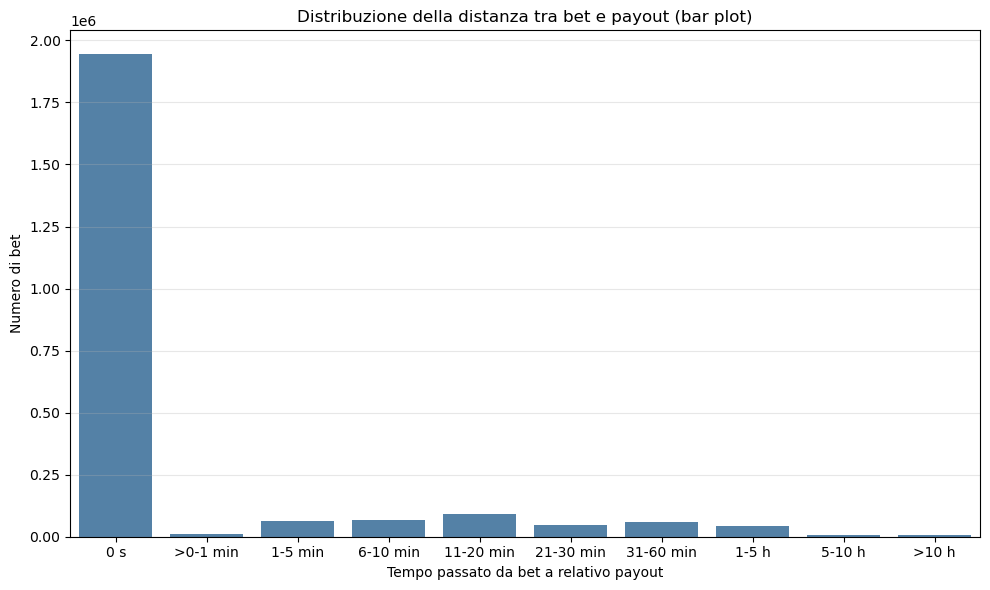

In [13]:
ValidPairsBarPlot = validPairs.copy()
ValidPairsBarPlot["timeIntervals"] = pd.cut(
    ValidPairsBarPlot["distanceMinutes"],
    bins=[-0.001,0,1,5,10,20,30,60,300,600,float("inf")]
    ,
    labels=[
        "0 s",">0-1 min", "1-5 min", "6-10 min","11-20 min","21-30 min", "31-60 min",
        "1-5 h", "5-10 h", ">10 h" 
    ]
)

ValidPairsDistribution = (
    ValidPairsBarPlot
    .groupby("timeIntervals", observed=False)
    .size()
    .rename("numberOfBetPayout")
    .reset_index()
)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=ValidPairsDistribution,
    x="timeIntervals",
    y="numberOfBetPayout",
    color="steelblue"
)

plt.xlabel("Tempo passato da bet a relativo payout")
plt.ylabel("Numero di bet")
plt.title("Distribuzione della distanza tra bet e payout (bar plot)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### 2.4.2) Distribuzione continua della coda dei tempi di payout

L'**istogramma** mostra la distribuzione del tempo, espresso in minuti, tra ciascuna bet e il payout associato, escludendo le coppie con distanza pari a zero in quanto l logaritmo non è definito in 0.Le scale logaritmiche permettono di evidenziare le code della distribuzione. Dal grafico si può osservare che la distribuzione è fortemente concentrata sui tempi di attesa più brevi, ma che comunque esiste una coda composta da pochi payout molto tardivi

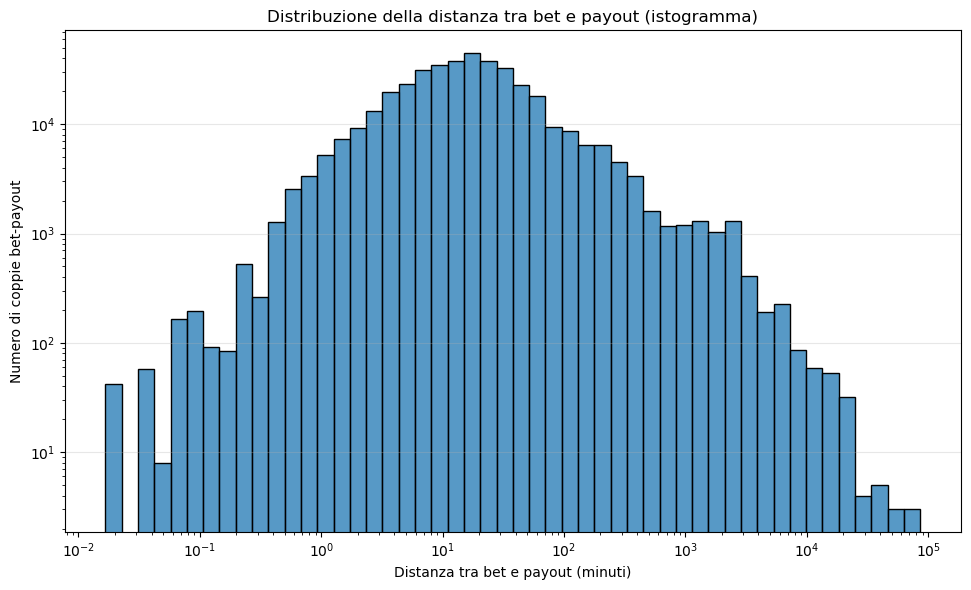

In [14]:
validPairsPositive = validPairs.loc[
    validPairs["distanceMinutes"] > 0
]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=validPairsPositive,
    x="distanceMinutes",
    bins=50,
    log_scale=(True, False)
)

plt.xlabel("Distanza tra bet e payout (minuti)")
plt.ylabel("Numero di coppie bet-payout")
plt.title("Distribuzione della distanza tra bet e payout (istogramma)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.yscale("log")

plt.show()

### 2.5) Analisi dei tre indirizzi più popolari

Sono state eseguite le seguenti analisi per i tre indirizzi più popolari:
* **Distribuzione temporale delle bet**: 
 è stato analizzato come le puntate sono distribuite nel tempo, utilizzando diverse scale temporali (ad esempio:per ora, per giorno, per settimana).
* **Analisi correlazione tra fee e amount della bet**: è stata verificata l’eventuale presenza di una correlazione tra le fee di transazione e l’importo scommesso
* **Intervallo tra bet consecutive**: è stata anaalizzata la distribuzione del tempo intercorso tra una puntata e la successiva.

Nella cella seguente sono stati ricavati i top 3 indirizzi di betting più popolari e vengono recuperate le statistiche delle transizioni di bet rivolte proprio a quegli indirizzi. E' possibile vedere il `dataframe top_3_names_stats`, dove queste informazioni vengono immagazzinate

In [15]:
addressPopularity = satoshiTransactions.groupby(['Name','Address'])['txId'].nunique()
top_3_names = addressPopularity.sort_values(ascending=False).head(3)

top_3_names_df = (
    top_3_names
    .rename("numberOfBets")
    .reset_index()
    .rename(columns={'Address': 'address'})
)

top_3_names_stats = pd.merge(
    betTransactions,
    top_3_names_df,
    on='address',
    how='inner'
)
timeS_top_3_names_stats = top_3_names_stats.set_index('datetime_utc').sort_index()
display(top_3_names_stats)


,timestamp,blockId,txId,isCoinbase,fee,fee_btc,datetime_utc,position,addressId,amount_satoshi,scriptType,amount_btc,address,Name,numberOfBets
0,1335029321,176629,2883983,0,50000,0.0005,2012-04-21 17:28:41+00:00,1,3517367,500000000,2,5.000,1dice9wcMu5hLF4g81u8nioL5mmSHTApw,lessthan 48000,235719
1,1335032189,176632,2884218,0,50000,0.0005,2012-04-21 18:16:29+00:00,0,3517636,2000000,2,0.020,1dice97ECuByXAvqXpaYzSaQuPVvrtmz6,lessthan 32768,346206
2,1335033873,176634,2884336,0,500000,0.0050,2012-04-21 18:44:33+00:00,0,3517636,5000000,2,0.050,1dice97ECuByXAvqXpaYzSaQuPVvrtmz6,lessthan 32768,346206
3,1335066618,176695,2887087,0,0,0.0000,2012-04-22 03:50:18+00:00,0,3517636,25000000,2,0.250,1dice97ECuByXAvqXpaYzSaQuPVvrtmz6,lessthan 32768,346206
4,1335079749,176719,2887926,0,50000,0.0005,2012-04-22 07:29:09+00:00,1,3517636,100000,2,0.001,1dice97ECuByXAvqXpaYzSaQuPVvrtmz6,lessthan 32768,346206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1394103,1356997957,214562,10572802,0,50000,0.0005,2012-12-31 23:52:37+00:00,1,3524394,20000000,2,0.200,1dice8EMZmqKvrGE4Qc9bUFf9PX3xaYDp,lessthan 32000,810212
1394104,1356997957,214562,10572811,0,50000,0.0005,2012-12-31 23:52:37+00:00,0,3517636,30000000,2,0.300,1dice97ECuByXAvqXpaYzSaQuPVvrtmz6,lessthan 32768,346206
1394105,1356997957,214562,10572811,0,50000,0.0005,2012-12-31 23:52:37+00:00,1,3524394,20000000,2,0.200,1dice8EMZmqKvrGE4Qc9bUFf9PX3xaYDp,lessthan 32000,810212
1394106,1356997957,214562,10572820,0,100000,0.0010,2012-12-31 23:52:37+00:00,0,3517636,20000000,2,0.200,1dice97ECuByXAvqXpaYzSaQuPVvrtmz6,lessthan 32768,346206


#### 2.5.1) Analisi della distribuzione delle puntate nel tempo
vengono utilizzate diverse scale temporali: per ora, per giorno, per settimana.

La cella raggruppa le transazioni dei tre indirizzi più popolari e conta le bet distinte, tramite `txId`, su scala oraria, giornaliera e settimanale.

In [16]:

top_3_names_stats_hour = (
    timeS_top_3_names_stats
    .groupby("Name")
    .resample('h')["txId"]
    .nunique()
    .rename("numberOfBets")
    .reset_index()
)

top_3_names_stats_day = (
    timeS_top_3_names_stats
    .groupby("Name")
    .resample('D')["txId"]
    .nunique()
    .rename("numberOfBets")
    .reset_index()
)
top_3_names_stats_week = (
    timeS_top_3_names_stats
    .groupby("Name")
    .resample('W')["txId"]
    .nunique()
    .rename("numberOfBets")
    .reset_index()
)


#### 2.5.1.1) Visualizzazione su scala oraria, giornaliera e settimanale

I tre grafici confrontano l'andamento delle puntate dei tre indirizzi più popolari usando differenti livelli di aggregazione temporale. Le tre aggregazioni mostrano che `lessthan 32000` è l’indirizzo più attivo e raggiunge il massimo nel giugno 2012. Il grafico orario evidenzia numerosi picchi isolati, mentre le aggregazioni giornaliera e settimanale rendono più leggibile l’andamento generale. Dopo il picco iniziale, l’attività diminuisce e si stabilizza su livelli inferiori, pur rimanendo generalmente superiore a quella degli altri due indirizzi. `lessthan 32768` registra una maggiore attività a maggio e negli ultimi mesi dell’anno, mentre `lessthan 48000` presenta volumi più contenuti.

Il grafico orario evidenzia una forte variabilità e numerosi picchi a breve termine. Le aggregazioni giornaliera e settimanale attenuano queste oscillazioni e rendono più evidente l’andamento generale

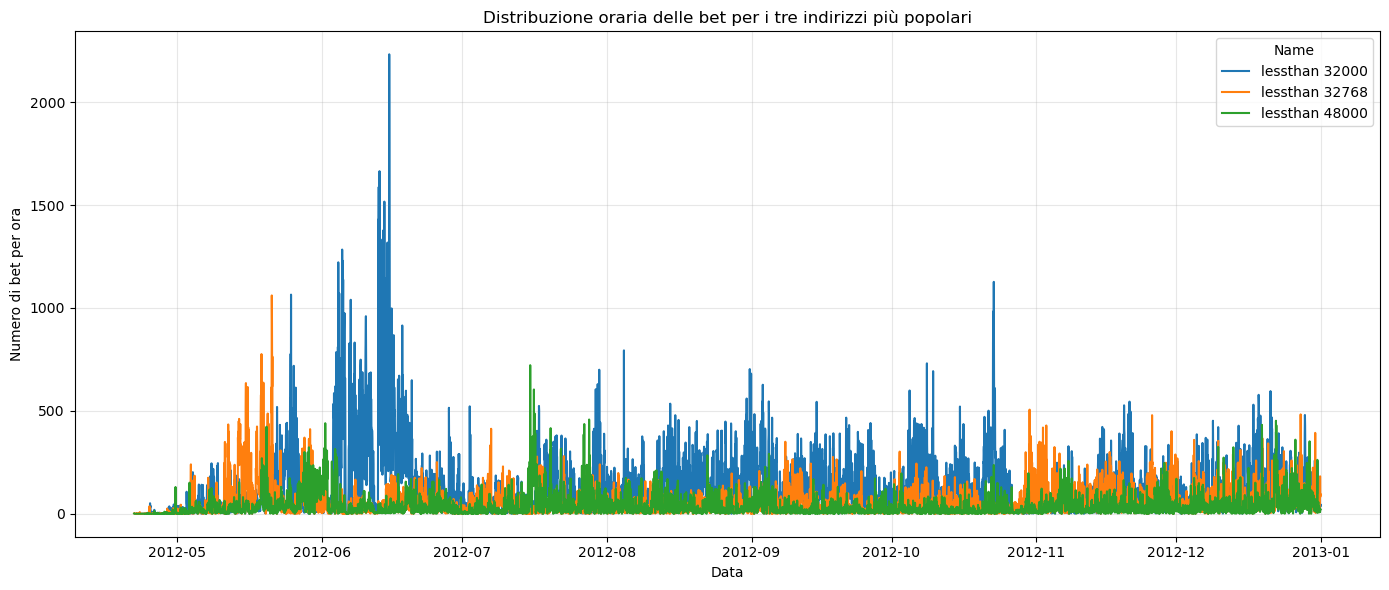

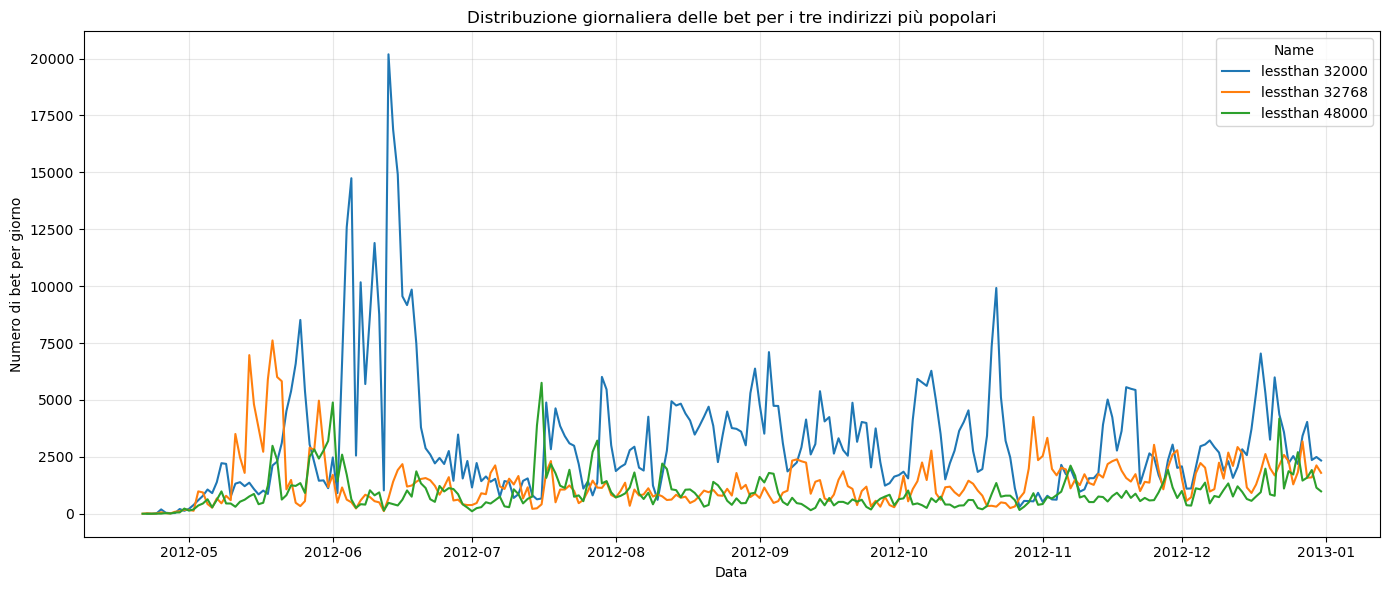

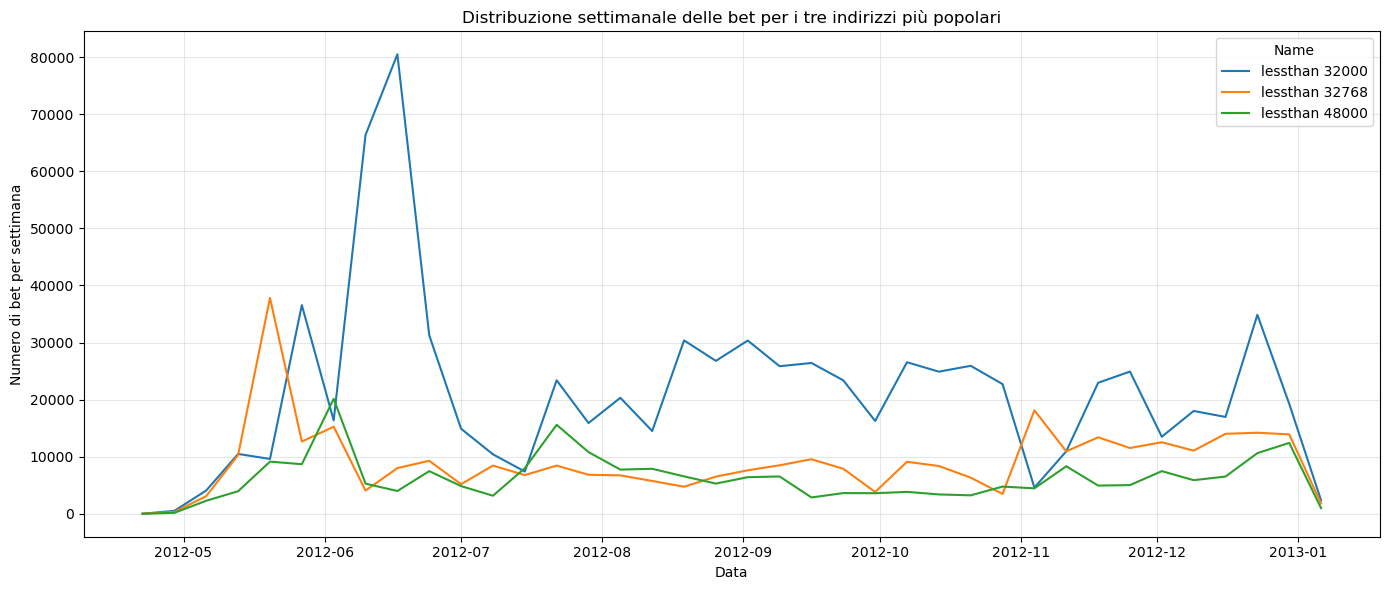

In [17]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=top_3_names_stats_hour,
    x="datetime_utc",
    y="numberOfBets",
    hue="Name"
)

plt.xlabel("Data")
plt.ylabel("Numero di bet per ora")
plt.title("Distribuzione oraria delle bet per i tre indirizzi più popolari")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 6))

sns.lineplot(
    data=top_3_names_stats_day,
    x="datetime_utc",
    y="numberOfBets",
    hue="Name"
)

plt.xlabel("Data")
plt.ylabel("Numero di bet per giorno")
plt.title("Distribuzione giornaliera delle bet per i tre indirizzi più popolari")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=top_3_names_stats_week,
    x="datetime_utc",
    y="numberOfBets",
    hue="Name"
)

plt.xlabel("Data")
plt.ylabel("Numero di bet per settimana")
plt.title("Distribuzione settimanale delle bet per i tre indirizzi più popolari")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 2.5.2) Analisi della correlazione tra fee e amount della bet
Verificare l’eventuale presenza di una correlazione tra le fee di transazione e l’importo scommesso (scatter plot).

Il codice raggruppa i dati per indirizzo di betting (Name) e transazione (txId), ottenendo una riga per ogni bet distinta. Calcola `fee` e `betAmount` per ogni bet sia in Satoshi che in Bitcoin

In [18]:
feeImportCorrelation = (
    top_3_names_stats
    .groupby(["Name","txId"], as_index=False)
    .agg(
        betAmountSatoshi=("amount_satoshi", "sum"),
        fee=("fee", "first"),
        betAmountBtc=("amount_btc","sum"),
        fee_btc=("fee_btc", "first")
    )
)
display(feeImportCorrelation)

,Name,txId,betAmountSatoshi,fee,betAmountBtc,fee_btc
0,lessthan 32000,2890967,100000,50000,0.001,0.0005
1,lessthan 32000,2890972,100000,50000,0.001,0.0005
2,lessthan 32000,2903154,100000,50000,0.001,0.0005
3,lessthan 32000,2903347,100000,50000,0.001,0.0005
4,lessthan 32000,2903353,100000,50000,0.001,0.0005
...,...,...,...,...,...,...
1392132,lessthan 48000,10572727,8000000,50000,0.080,0.0005
1392133,lessthan 48000,10572734,8000000,50000,0.080,0.0005
1392134,lessthan 48000,10572744,8000000,100000,0.080,0.0010
1392135,lessthan 48000,10572760,16400000,50000,0.164,0.0005


#### 2.5.2.1) Grafici della relazione tra fee e importo

La cella genera uno **scatter plot** separato per ciascuno dei tre indirizzi principali, confrontando commissione e importo della bet in BTC su scale logaritmiche. Dai grafici non emerge una correlazione forte tra fee e importo della bet.

I grafici non evidenziano una relazione chiara tra la fee e l’importo della bet. La presenza di bande verticali indica che commissioni simili vengono applicate a puntate di importo molto diverso. I tre indirizzi presentano comportamenti analoghi, con una forte concentrazione delle osservazioni in alcuni valori di fee e la presenza di pochi valori estremi. E'inoltre possibile notare che le transazioni con fee basse sono poche, perchè i miner non sono incentivati a inserirle nei blocchi.

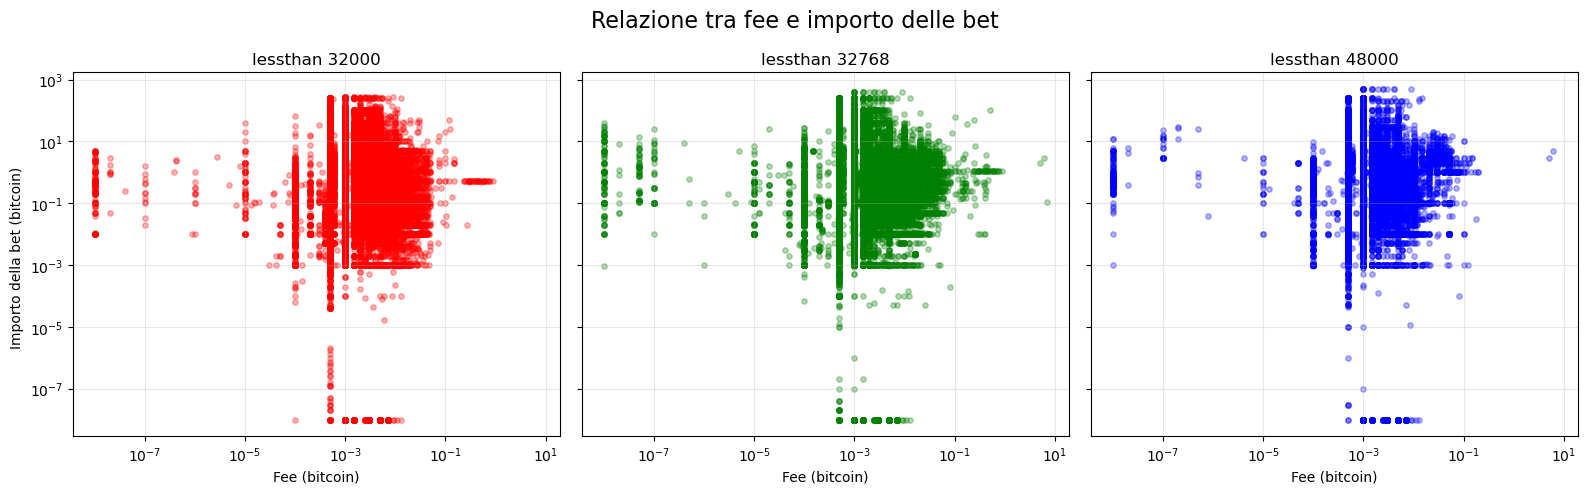

In [19]:
colors = ['red','green','blue']
i = 0
names = feeImportCorrelation["Name"].unique()

fig, axes = plt.subplots( #subplot restituisce coppia (fig,axes) dove fig intera figura, axes singoli grafici
    1,
    len(names),
    figsize=(16, 5),
    sharex=True,
    sharey=True
)

fig.suptitle(
    "Relazione tra fee e importo delle bet",
    fontsize=16
)

for axis, name in zip(axes, names): #zip() abbina gli elementi di due sequenze posizione per posizione
    subset = feeImportCorrelation[
        feeImportCorrelation["Name"] == name
    ]

    axis.scatter(
        subset["fee_btc"],
        subset["betAmountBtc"],
        s=15,
        alpha=0.3,
        color= colors[i],
    )

    axis.set_title(name)
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlabel("Fee (bitcoin)")
    axis.grid(alpha=0.3)
    i += 1

axes[0].set_ylabel("Importo della bet (bitcoin) ")

plt.tight_layout()
plt.show()

#### 2.5.3) Intervallo tra bet consecutive

Analizzare la distribuzione del tempo intercorso tra una puntata e la successiva

La cella ordina cronologicamente le bet dei tre indirizzi più popolari e rimuove gli eventuali `txId` duplicati. Per ogni indirizzo calcola il tempo trascorso dalla bet precedente, esprimendolo in secondi, minuti e ore. Infine, rimuove le righe prive di un intervallo precedente (quindi le prime di ogni gruppo) per preparare i dati destinati ai grafici. Viene mostrato in fondo il dataframe `plotData`, con i dati pronti per essere visualizzati su un grafico.

In [20]:
consecutiveBets = (
    top_3_names_stats[["Name","txId","datetime_utc"]]
    .drop_duplicates(subset="txId")
    .sort_values(["Name","datetime_utc"])
)

consecutiveBets["timeFromLastBet"] = (
    consecutiveBets
    .groupby("Name")["datetime_utc"]
    .diff()
)

consecutiveBets["secondsFromLastBet"] = (
    consecutiveBets["timeFromLastBet"]
    .dt.total_seconds()
)
consecutiveBets["minutesFromLastBet"] = (
    consecutiveBets["timeFromLastBet"]
    .dt.total_seconds()/60
)
consecutiveBets["hoursFromLastBet"] = (
    consecutiveBets["timeFromLastBet"]
    .dt.total_seconds()/3600
)
plotData = consecutiveBets.dropna(
    subset=["secondsFromLastBet"]
).copy()

display(plotData)


,Name,txId,datetime_utc,timeFromLastBet,secondsFromLastBet,minutesFromLastBet,hoursFromLastBet
8,lessthan 32000,2890972,2012-04-22 18:22:51+00:00,0 days 00:00:00,0.0,0.000000,0.000000
33,lessthan 32000,2903154,2012-04-24 12:18:11+00:00,1 days 17:55:20,150920.0,2515.333333,41.922222
42,lessthan 32000,2904651,2012-04-24 17:39:49+00:00,0 days 05:21:38,19298.0,321.633333,5.360556
45,lessthan 32000,2904655,2012-04-24 17:39:49+00:00,0 days 00:00:00,0.0,0.000000,0.000000
49,lessthan 32000,2905349,2012-04-24 18:51:29+00:00,0 days 01:11:40,4300.0,71.666667,1.194444
...,...,...,...,...,...,...,...
1394082,lessthan 48000,10572727,2012-12-31 23:52:37+00:00,0 days 00:00:00,0.0,0.000000,0.000000
1394085,lessthan 48000,10572734,2012-12-31 23:52:37+00:00,0 days 00:00:00,0.0,0.000000,0.000000
1394088,lessthan 48000,10572744,2012-12-31 23:52:37+00:00,0 days 00:00:00,0.0,0.000000,0.000000
1394093,lessthan 48000,10572760,2012-12-31 23:52:37+00:00,0 days 00:00:00,0.0,0.000000,0.000000


#### 2.5.3.1) Distribuzione degli intervalli per classi

Gli intervalli tra bet consecutive vengono raggruppati in fasce temporali; per ogni indirizzo viene calcolata la percentuale relativa e costruito un **bar plot** separato. 

Dai grafici si può notare che per tutti gli indirizzi prevalgono nettamente gli intervalli pari a zero, probabilmente perché numerose bet appartengono allo stesso blocco e condividono il medesimo timestamp. Gli intervalli di pochi secondi sono poco frequenti, mentre tra i valori positivi prevalgono le attese superiori a un minuto.


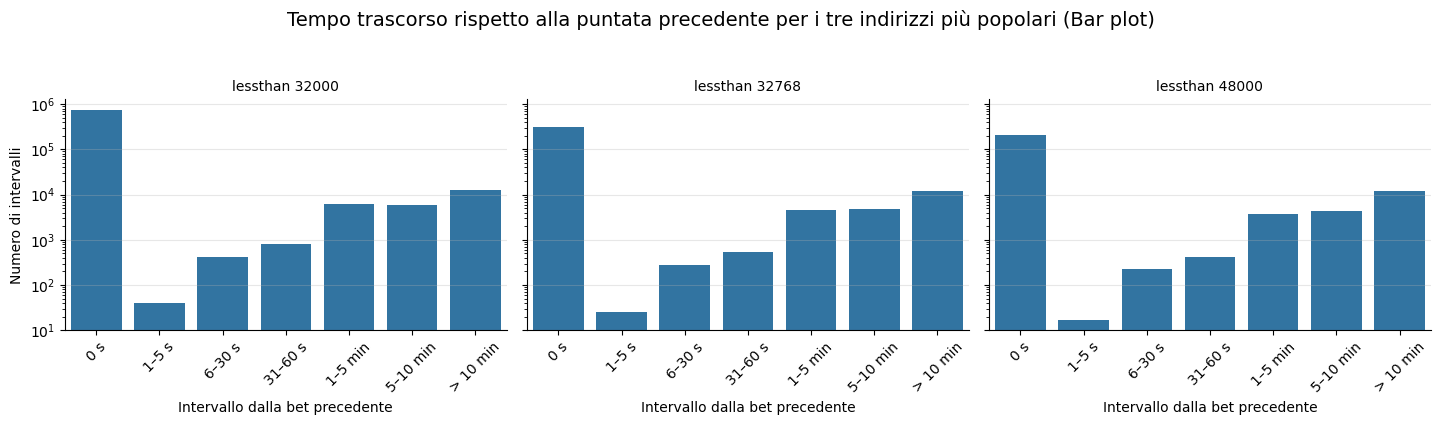

In [21]:
plotData["timeRange"] = pd.cut(
    plotData["secondsFromLastBet"],
    bins=[-0.001,0,5,30,60,300,600,float("inf")],
    labels=["0 s","1–5 s","6–30 s","31–60 s","1–5 min","5–10 min","> 10 min"]
)

timeDistribution = (
    plotData
    .groupby(
        ["Name", "timeRange"],
        observed=True
    )
    .size() 
    .rename("numberOfIntervals")
    .reset_index()
)

graph = sns.catplot(
    data=timeDistribution,
    x="timeRange",
    y="numberOfIntervals",
    col="Name",
    kind="bar",
    col_wrap=3,
    height=4,
    aspect=1.2,
    sharey=True
)

graph.set_axis_labels(
    "Intervallo dalla bet precedente",
    "Numero di intervalli"
)

graph.set_titles("{col_name}")

for axis in graph.axes.flat:
    axis.tick_params(
        axis="x",
        rotation=45
    )
    axis.grid(
        axis="y",
        alpha=0.3
    )

graph.figure.suptitle(
    "Tempo trascorso rispetto alla puntata precedente per i tre indirizzi più popolari (Bar plot)",
    fontsize=14,
    y=1.05
)

plt.yscale("log")
plt.tight_layout()
plt.show()

#### 2.5.3.2) Istogrammi delle code degli intervalli tra bet

La cella presenta, per ciascuno dei tre indirizzi, la distribuzione dei minuti trascorsi dalla puntata precedente mediante **istogrammi** con assi logaritmici.

Gli istogrammi, ottenuti escludendo gli intervalli pari a zero, evidenziano un andamento simile per tutti e tre gli indirizzi. La maggior parte delle bet consecutive è separata da pochi minuti o alcune decine di minuti. Le distribuzioni presentano inoltre una lunga coda verso destra, dovuta a un numero limitato di periodi di inattività particolarmente lunghi. L’indirizzo `lessthan 32000` registra il maggior numero di intervalli, coerentemente con la sua maggiore frequenza di utilizzo.

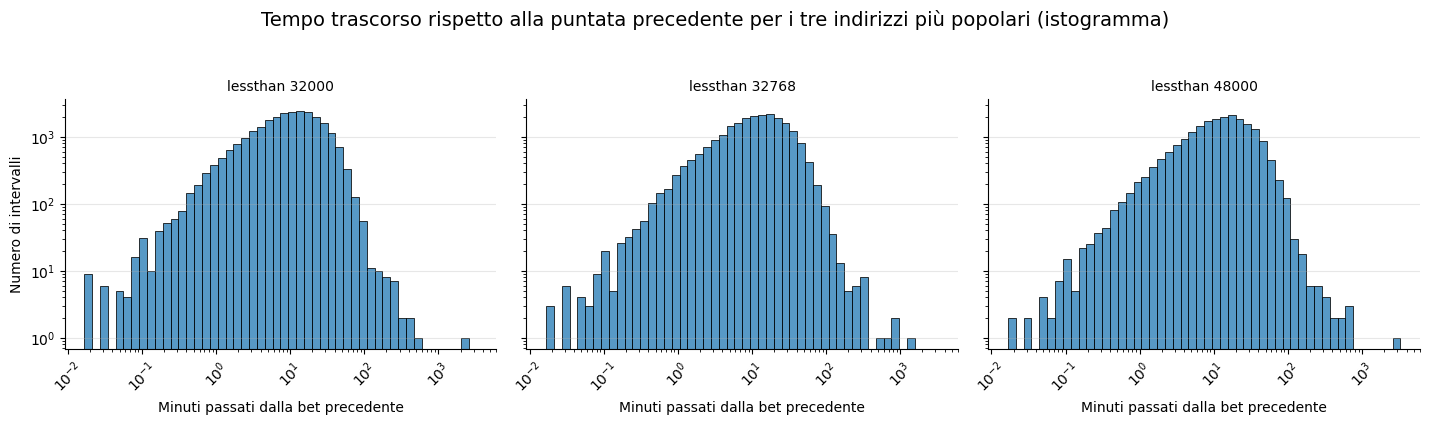

In [22]:
plotDataPositive = plotData.loc[
    plotData["minutesFromLastBet"] > 0
]

graph = sns.displot(
    data=plotData,
    x="minutesFromLastBet",
    col="Name",
    col_wrap=3,
    kind="hist",
    bins=50,
    height=4,
    aspect=1.2,
    log_scale=(True, False),
    facet_kws={
        "sharex": True,
        "sharey": True
    }
)

graph.set_axis_labels(
    "Minuti passati dalla bet precedente",
    "Numero di intervalli"
)

graph.set_titles("{col_name}")

for axis in graph.axes.flat:
    axis.tick_params(
        axis="x",
        rotation=45
    )
    axis.grid(
        axis="y",
        alpha=0.3
    )
    axis.set_yscale("log")

graph.figure.suptitle(
    "Tempo trascorso rispetto alla puntata precedente per i tre indirizzi più popolari (istogramma)",
    fontsize=14,
    y=1.05
)

plt.tight_layout()
plt.show()

## Fase 3 — Analisi di sequenze di bet

In questa analisi verranno considerate solamente le **catene di simple bet**, dove con simple bet si intende transazioni caratterizzate da un solo input e da esattamente due output, di cui uno destinato a un indirizzo `1dice` di SatoshiDice e l’altro identificato come output di resto (change).

Due restricted bet consecutive appartengono alla stessa catena se e solo se l’input della seconda coincide con l’output di resto della prima e l'altro output è indirizzato a uno degli indirizzi `1dice`. In tal modo, ogni catena rappresenta una sequenza lineare di transazioni in cui il resto di una puntata viene riutilizzato come input della puntata successiva.

L’analisi sarà limitata alle simple bet associate all’indirizzo 1dice caratterizzato dal maggiornumero di transazioni nel dataset.

Al fine di individuare tali catene, viene costruito un grafo diretto **𝐺 = (𝑉, 𝐸)**, in cui:
* ogni nodo 𝑣 ∈ 𝑉 rappresenta una singola simple bet;
* esiste un arco diretto (𝑣 , 𝑣 ) ∈ 𝐸 se e solo se l’ input della simple bet j corrisponde
all’ output di resto della simple bet 𝑖 ;ù
* a ciascun arco è associata un’etichetta che identifica l’indirizzo responsabile del
collegamento tra le due bet.

Nella cella seguente vengono individuate le transazioni con un solo input, necessarie per individuare le simple bet. Viene inoltr mostrato quante di queste transazioni esistono e il loro dataframe, `singleInputTransactions`

In [23]:
inputCounts = (
    inputs.groupby("txId")["txId"]
    .transform("size")
)
singleInputTransactions = inputs.loc[
    inputCounts == 1
]
display(len(singleInputTransactions))
display(singleInputTransactions)

7257855

,txId,prevTxId,prevTxPos
0,171,9,0
1,183,171,1
2,185,183,1
3,187,185,1
4,192,187,0
...,...,...,...
21378763,10572821,10572820,3
21378764,10572822,10572820,4
21378765,10572823,10572820,7
21378766,10572824,10572820,5


### 3.1) Selezione delle transazioni con due output

La cella individua le transazioni dirette all'indirizzo SatoshiDice più popolare che possiedono esattamente due output: uno di bet e uno interpretabile come resto, diretto ad un altro indirizzo. Viene mostrato numero di outputs totali, numero di transazioni totali e dataframe `twoOutputsBetTransactions` con tutti i dati

In [24]:
most_popular_address = addressPopularity.sort_values(ascending=False).reset_index().head(1)

mappingTransactionsOutput["isMostPopularAddress"] = (
    mappingTransactionsOutput["address"]
        .isin(most_popular_address["Address"])
)

mappingTransactionsOutput["outputCount"] = (
    mappingTransactionsOutput
    .groupby("txId")["txId"]
    .transform("size")
)

mappingTransactionsOutput["isBetAddress"] = (
    mappingTransactionsOutput["address"]
    .str.startswith("1dice", na=False)
)

mappingTransactionsOutput["hasBetAddress"] = (
    mappingTransactionsOutput
    .groupby("txId")["isBetAddress"]
    .transform("any")
)

mappingTransactionsOutput["hasMostPopularAddress"] = (
    mappingTransactionsOutput
    .groupby("txId")["isMostPopularAddress"]
    .transform("any")
)

mappingTransactionsOutput["hasBothBetAddresses"] = (
    mappingTransactionsOutput
    .groupby("txId")["isBetAddress"]
    .transform("all")
)

twoOutputsBetTransactions = mappingTransactionsOutput.loc[
    (mappingTransactionsOutput["outputCount"] == 2)
    & (mappingTransactionsOutput["hasMostPopularAddress"])
    & ~(mappingTransactionsOutput["hasBothBetAddresses"])
].copy()

print("Numero di righe:", len(twoOutputsBetTransactions))

print(
    "Numero di transazioni:",
    twoOutputsBetTransactions["txId"].nunique()
)

display(twoOutputsBetTransactions.sort_values(
    by=["txId","position"],
    ascending=True
))


Numero di righe: 1470208
Numero di transazioni: 735104


,timestamp,blockId,txId,isCoinbase,fee,fee_btc,datetime_utc,position,addressId,amount_satoshi,scriptType,amount_btc,address,isMostPopularAddress,outputCount,isBetAddress,hasBetAddress,hasMostPopularAddress,hasBothBetAddresses
6734162,1335118971,176781,2890967,0,50000,0.0005,2012-04-22 18:22:51+00:00,0,3524393,2800630,2,0.028006,1A4YPUgekvFBTpGWakSwuQMaxGaPTifDq3,False,2,False,True,True,False
6734163,1335118971,176781,2890967,0,50000,0.0005,2012-04-22 18:22:51+00:00,1,3524394,100000,2,0.001000,1dice8EMZmqKvrGE4Qc9bUFf9PX3xaYDp,True,2,True,True,True,False
6734172,1335118971,176781,2890972,0,50000,0.0005,2012-04-22 18:22:51+00:00,0,3524398,2650630,2,0.026506,1AmB2fS5Yd3ghm5gnATNJRi7E7CcxwFyPk,False,2,False,True,True,False
6734173,1335118971,176781,2890972,0,50000,0.0005,2012-04-22 18:22:51+00:00,1,3524394,100000,2,0.001000,1dice8EMZmqKvrGE4Qc9bUFf9PX3xaYDp,True,2,True,True,True,False
6769431,1335293489,177055,2905349,0,50000,0.0005,2012-04-24 18:51:29+00:00,0,3524394,400000,2,0.004000,1dice8EMZmqKvrGE4Qc9bUFf9PX3xaYDp,True,2,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24570786,1356996072,214558,10571901,0,350000,0.0035,2012-12-31 23:21:12+00:00,1,8707915,1942460,2,0.019425,1DYve98WqJQmx6cDdW2EQFpnqfwptjV4e9,False,2,False,True,True,False
24571818,1356996754,214559,10572338,0,50000,0.0005,2012-12-31 23:32:34+00:00,0,8708602,1167339,2,0.011673,1GfipQ9LadLRpRV1qMqLMJwBfR2m8Xx3p1,False,2,False,True,True,False
24571819,1356996754,214559,10572338,0,50000,0.0005,2012-12-31 23:32:34+00:00,1,3524394,3000000,2,0.030000,1dice8EMZmqKvrGE4Qc9bUFf9PX3xaYDp,True,2,True,True,True,False
24572086,1356997591,214561,10572428,0,0,0.0000,2012-12-31 23:46:31+00:00,0,3524394,200000000,2,2.000000,1dice8EMZmqKvrGE4Qc9bUFf9PX3xaYDp,True,2,True,True,True,False


### 3.2) Individuazione dei collegamenti tra simple bet

Dopo aver separato gli output di resto, la cella collega due simple bet quando l'unico input della seconda spende esattamente il resto prodotto dalla prima. Il dataframe `betLinks` contiene informazioni degli output collegati alle informazioni degli input che li hanno consumati

In [25]:
simpleBetOutputs = twoOutputsBetTransactions[["txId","position","address","isBetAddress","amount_btc"]]

simpleBets = (
    simpleBetOutputs
    .merge(
        singleInputTransactions,
        on = "txId",
        how = "inner"
    )
)

changeOutputs = (
    simpleBets.loc[
        ~simpleBets["isBetAddress"],
        ["txId", "position", "address" ]
    ]
    .drop_duplicates()
    .rename(columns={
        "txId": "previousBetTxId",
        "position": "previousBetPosition",
        "address": "changeAddress"
    })
)

simpleBetIds = simpleBets["txId"].unique()

simpleBetInputs = (
    singleInputTransactions.loc[
        singleInputTransactions["txId"].isin(simpleBetIds),
        ["txId", "prevTxId", "prevTxPos"]
    ]
    .rename(columns={
        "txId": "currentBetTxId"
    })
)

betLinks = simpleBetInputs.merge(
    changeOutputs,
    left_on=["prevTxId", "prevTxPos"],
    right_on=[
        "previousBetTxId",
        "previousBetPosition"
    ],
    how="inner"
)
display(betLinks)

,currentBetTxId,prevTxId,prevTxPos,previousBetTxId,previousBetPosition,changeAddress
0,2890972,2890967,0,2890967,0,1A4YPUgekvFBTpGWakSwuQMaxGaPTifDq3
1,2908490,2908434,0,2908434,0,18nGa7G7BaG659BXWkzNo1uAdXZDNwpXB1
2,2908500,2908478,0,2908478,0,1JSP9JzRE95dyAZjH7gx8PiMQ5GD9Bzsii
3,2908501,2908479,0,2908479,0,1KV3W3RiHk4sPw3gVVMEXfUWZJiZ9PET2K
4,2908502,2908480,0,2908480,0,18EhHZZjimnmtxpF8MScrRsBX7JSwuEUmg
...,...,...,...,...,...,...
311837,10570747,10570745,1,10570745,1,18b8YqBkD6ENSgz241cfEFh3L5e9eV8vEH
311838,10570795,10570749,1,10570749,1,18b8YqBkD6ENSgz241cfEFh3L5e9eV8vEH
311839,10570883,10570674,1,10570674,1,18b8YqBkD6ENSgz241cfEFh3L5e9eV8vEH
311840,10570885,10570747,1,10570747,1,18b8YqBkD6ENSgz241cfEFh3L5e9eV8vEH


### 3.3) Costruzione del grafo diretto

La cella costruisce un grafo diretto in cui ogni nodo rappresenta una simple bet e ogni arco collega una bet alla successiva quando questa spende il suo output di resto. L’arco viene etichettato con l’indirizzo associato al resto utilizzato nel collegamento

In [26]:
import networkx as nx

g = nx.DiGraph()

for previousBet, currentBet, changeAddress in zip(betLinks["previousBetTxId"], betLinks["currentBetTxId"], betLinks["changeAddress"]):   
    g.add_edge(previousBet, currentBet, label = changeAddress)

print("Numero di nodi:", g.number_of_nodes())
print("Numero di archi:", g.number_of_edges())

Numero di nodi: 395969
Numero di archi: 311842


### 3.4) Analisi sul grafo

#### Identificare le catene di simple bet come cammini nel grafo, calcolare distribuzione delle lunghezze delle catene per classi

La cella individua le componenti debolmente connesse del grafo, considerate come catene di simple bet. Successivamente, per ogni catena calcola:
- **chainId**: identificativo progressivo
- **numberOfNodes**: numero di simple bet
- **numberOfEdges**: numero di collegamenti tra bet consecutive
Infine mostra il numero totale di catene e le 30 catene più lunghe, ordinate per numero di nodi.

In [27]:
components = list(
    nx.weakly_connected_components(g)
)

print("Numero di catene:", len(components))

chainStats = pd.DataFrame([
    {
        "chainId": chainId,
        "numberOfNodes": len(component),
        "numberOfEdges": g.subgraph(component).number_of_edges()
    }
    for chainId, component in enumerate(components,start=1)
])
display(chainStats.sort_values(by="numberOfNodes", ascending=False).head(30))

Numero di catene: 84127


,chainId,numberOfNodes,numberOfEdges
10937,10938,717,716
11804,11805,442,441
10125,10126,352,351
8192,8193,293,292
4533,4534,273,272
12093,12094,246,245
62657,62658,243,242
10358,10359,235,234
8785,8786,233,232
8748,8749,229,228


#### 3.4.1) Rappresentazione grafica della lunghezza delle catene tramite bar plot

La cella raggruppa le catene in intervalli basati sul numero di nodi e visualizza quante catene ricadono in ciascuna classe. Dal bar plot si può osservare che la distribuzione è fortemente concentrata sulle catene brevi: la maggior parte è formata da due o tre nodes, mentre la frequenza diminuisce rapidamente all’aumentare della lunghezza. Sono comunque presenti alcune catene molto lunghe, anche superiori a 100 nodi, che mostrano un riutilizzo persistente dell’output di resto in puntate consecutive.


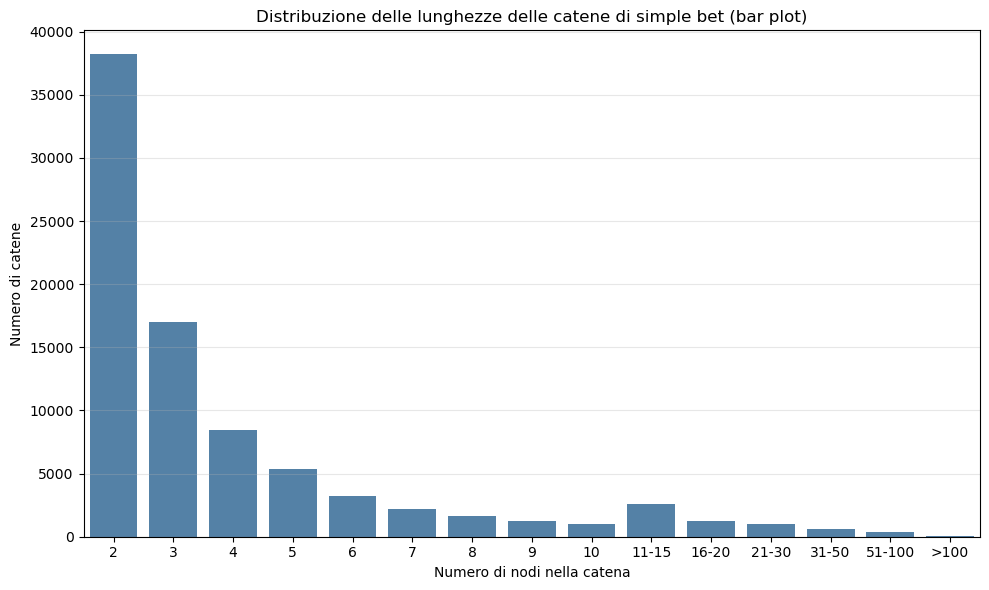

In [28]:
chainStatsPlot = chainStats.copy()
chainStatsPlot["intervals"] = pd.cut(
    chainStatsPlot["numberOfNodes"],
    bins=[
        1.5, 2.5, 3.5, 4.5, 5.5,
        6.5, 7.5, 8.5, 9.5, 10.5,
        15.5, 20.5, 30.5, 50.5, 100.5, float("inf")
    ],
    labels=[
        "2", "3", "4", "5", "6",
        "7", "8", "9", "10",
        "11-15", "16-20", "21-30",
        "31-50", "51-100", ">100" 
    ]
)

chainDistribution = (
    chainStatsPlot
    .groupby("intervals", observed=False)
    .size()
    .rename("numberOfChains")
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=chainDistribution,
    x="intervals",
    y="numberOfChains",
    color="steelblue"
)

plt.xlabel("Numero di nodi nella catena")
plt.ylabel("Numero di catene")
plt.title("Distribuzione delle lunghezze delle catene di simple bet (bar plot)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



## Fase 4 — Scraping di WalletExplorer per verificare appartenenza a wallet

Limitatamente alle ℎ catene di bet di lunghezza massima individuate nella fase precedente, è stato verificato che gli indirizzi associati agli archi di ciascuna catena appartengano a un medesimo wallet.

A tal fine è stato effettuato web scraping sul servizio WalletExplorer, utilizzando
le informazioni disponibili per determinare a quale wallet appartiene un determinato indirizzo.

**Wallet**: cluster di indirizzi Bitcoin che si ritiene appartengano alla stessa entità.
WalletExplorer raggruppa indirizzi la multi-input heuristic che prevede che, se più
indirizzi compaiono come input nella stessa transazione, probabilmente sono controllati dallo
stesso utente.

L’analisi stabilisce se:
- tutti gli indirizzi di una catena sono riconducibili a un unico wallet;
- oppure se la catena coinvolge indirizzi appartenenti a wallet distinti.
  
I risultati dell’analisi includono, per ciascuna catena individuata, le seguenti
informazioni:
- identificativo univoco della catena;
- lunghezza della catena (espressa in numero di nodi o, alternativamente, di archi);
- numero totale di indirizzi coinvolti;
- numero di wallet distinti identificati;
- percentuale di indirizzi riconducibili al wallet predominante;
- identificativo del wallet principale: nel caso in cui il wallet principale sia stato deanonimizzato, l’identificativo corrisponderà al
nome del servizio così come riportato su WalletExplorer; in caso contrario, sarà utilizzato l’identificativo numerico assegnato da WalletExplorer al wallet stesso.

La cella definisce una funzione per visualizzare graficamente una catena di simple bet e una funzione per estrarre
gli indirizzi associati agli archi del sottografo.

In [29]:
def drawBetChain(
    subgraph,
    title="Catena di simple bet",
    showNodes=True
):

    print("Numero di nodi:", subgraph.number_of_nodes())
    print("Numero di archi:", subgraph.number_of_edges())

    positions = nx.spring_layout(
        subgraph,
        iterations=15,
        seed=1721
    )

    fig, axis = plt.subplots(
        figsize=(14, 7)
    )

    nx.draw(
        subgraph,
        positions,
        ax=axis,
        with_labels=False,
        node_size=20,
        node_color="lightblue",
        arrows=True,
        font_size=8,
        width=0.5
    )

    
    axis.set_title(title)
    axis.axis("off")

    plt.tight_layout()
    plt.show()

def buildLabelsList(
    subgraph
):
    return [
        attributes["label"]
        for _,_,attributes in subgraph.edges(data=True)
    ]

### 4.1) Recupero dei wallet associati agli indirizzi

La funzione visita WalletExplorer tramite Selenium, ricava il wallet associato a ogni indirizzo della catena e aggiorna una tabella riepilogativa con numerosità, wallet distinti e wallet predominante.

In [35]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import Select
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.keys import Keys
import time

def betChainInfoDf(chainNumber,subgraph, dataframe):
    
    labelsList = buildLabelsList(subgraph)
    numberOfDistinctLabels = len(set(labelsList))
    url = "https://www.walletexplorer.com/address/"
    driver=webdriver.Safari()
    print(driver.service.path)
    
    wallets = dict()
    walletsLength = dict()
    
    try:

        wait = WebDriverWait(driver, 10)
        
        for address in labelsList:
            driver.get(
                f"{url}{address}"
            )
            walletName = wait.until(EC.presence_of_element_located((By.CLASS_NAME,"wallet_name"))).text.strip("[]")
    
            wallets.setdefault(walletName, []).append(address)
            
            walletLengths = {walletName:len(addresses) for walletName, addresses in wallets.items()}
        
        mainWallet=max(walletLengths,
            key=walletLengths.get)
        
        perc_indirizzi_mainWallet = (len(wallets[mainWallet])/subgraph.number_of_edges())*100       

        dataframe.loc[len(dataframe)]={
        "id_catena": chainNumber,
        "lunghezza_catena": subgraph.number_of_nodes(),
        "indirizzi_coinvolti": numberOfDistinctLabels,
        "wallet_distinti": len(wallets),
        "perc_indirizzi_mainWallet": perc_indirizzi_mainWallet,
        "id_mainWallet": mainWallet
        }

    finally:
        driver.quit()
    return dataframe

### 4.2) Analisi delle catene di lunghezza massima

La cella seleziona le componenti più lunghe, ne disegna il sottografo e applica la procedura di raccolta delle informazioni sui wallet, mostrando infine i risultati aggregati.

Numero di nodi: 717
Numero di archi: 716


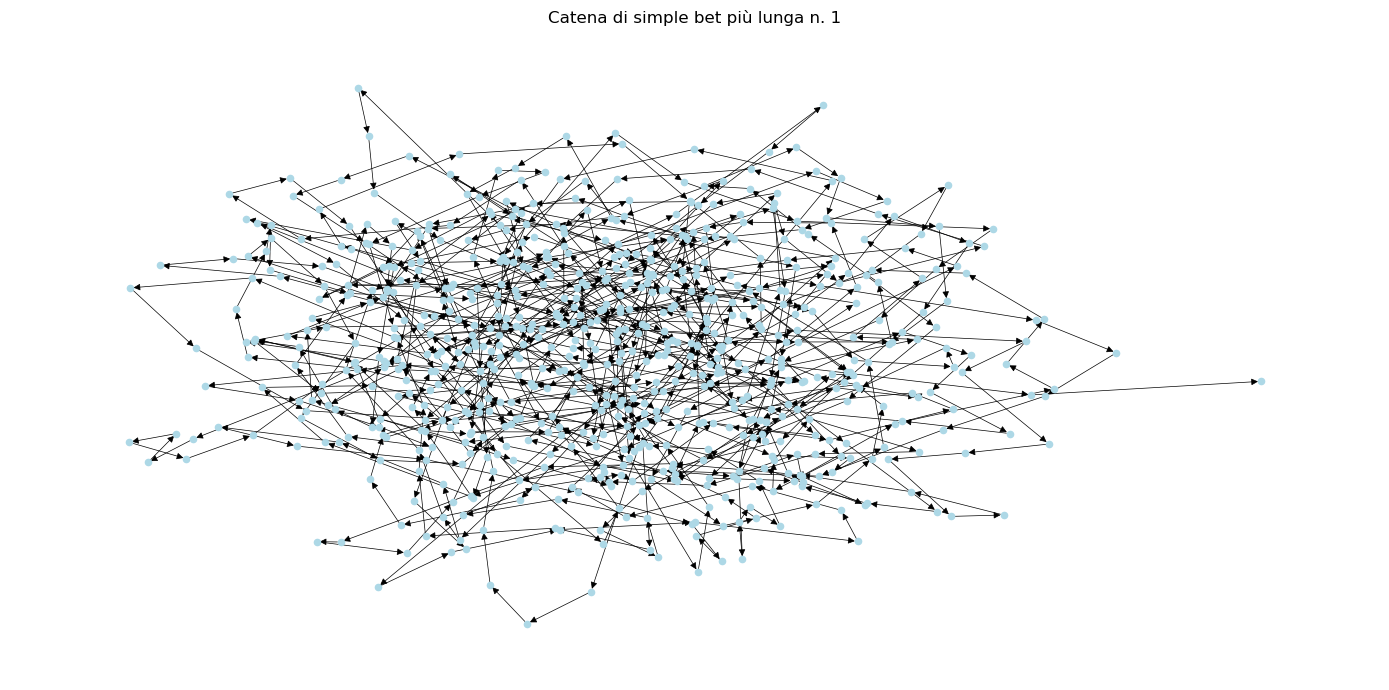

/usr/bin/safaridriver


,id_catena,lunghezza_catena,indirizzi_coinvolti,wallet_distinti,perc_indirizzi_mainWallet,id_mainWallet
0,1,717,716,76,50.139665,0025d633f8


In [36]:
dataframe = pd.DataFrame(
    columns=[
        "id_catena",
        "lunghezza_catena",
        "indirizzi_coinvolti",
        "wallet_distinti",
        "perc_indirizzi_mainWallet",
        "id_mainWallet"
    ]
)

maxLength = max(
    len(component)
    for component in components
)

maxLengthComponents = [
    component
    for component in components
    if len(component) == maxLength
]

for chainNumber, component in enumerate(maxLengthComponents,start=1):
    subgraph = g.subgraph(component)
    drawBetChain(subgraph,title=(f"Catena di simple bet più lunga n. {chainNumber}"))
    dataframe = betChainInfoDf(chainNumber, subgraph, dataframe)
display(dataframe)

Dalle informazioni ricavate sipra si può osservare che:
- esiste una sola catena di lunghezza h massima: contiene 717 simple bet
- gli archi coinvolgono 716 indirizzi distinti
- gli indirizzi sono associati a 76 wallet differenti, quindi la catena non è riconducibile a un unico wallet
- il wallet predominante è 0025d633f8, non è deanonimizzato e comprende circa il 50,14% degli indirizzi